# Compare MarS-FM Outputs to Paper Table 2

This notebook loads the per-run summary produced by
[`scripts/analysis/analyze_mdcath.py`](../scripts/analysis/analyze_mdcath.py)
(written to `workdir_out/analysis.csv` and friends) and places the numbers
side-by-side with the published Table 2 from
[Markov Autoregression / MarS-FM (arXiv:2509.24779)](https://arxiv.org/pdf/2509.24779).

Table 2 reports, for trajectories of 500 conformations averaged over 5 inference
runs:

* Pearson r ↑ for pairwise RMSD, global RMSF and per-target RMSF
* Forward KL ↓ and JSD ↓ of the radius of gyration distribution
* Forward KL ↓ and JSD ↓ of the secondary-structure-fraction distribution
* JSD ↓ of MSM stationary distributions
* MAE ↓ on folding free energy ΔGfold (kcal/mol)

In [9]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
REPO_ROOT = Path("..").resolve()
REPO_ROOT

PosixPath('/mnt/labs/home/atong/markov-autoregression')

## 1. Published Table 2 numbers

Values are transcribed from Table 2 of the paper as `mean ± std` across 5 inference runs.

In [10]:
# Each entry is (mean, std). Lower-better metrics are kept as-is; higher-better
# metrics (Pearson r) are tagged via the METRIC_DIRECTION dict below.
PAPER_TABLE2: dict[str, dict[str, tuple[float, float]]] = {
    "MD (Oracle)": {
        "Pairwise RMSD r":            (0.82, 0.014),
        "Global RMSF r":              (0.82, 0.012),
        "Per-target RMSF r":          (0.90, 0.005),
        "Gyration Radius KL":         (0.58, 0.020),
        "Gyration Radius JSD":        (0.07, 0.001),
        "Secondary Structures KL":    (0.61, 0.048),
        "Secondary Structures JSD":   (0.07, 0.003),
        "MSM JSD":                    (0.19, 0.006),
        "dG_fold MAE":                (0.90, 0.046),
    },
    "MDGen-100": {
        "Pairwise RMSD r":            (0.42, 0.047),
        "Global RMSF r":              (0.49, 0.018),
        "Per-target RMSF r":          (0.64, 0.007),
        "Gyration Radius KL":         (1.13, 0.025),
        "Gyration Radius JSD":        (0.15, 0.003),
        "Secondary Structures KL":    (1.17, 0.045),
        "Secondary Structures JSD":   (0.18, 0.005),
        "MSM JSD":                    (0.29, 0.005),
        "dG_fold MAE":                (1.21, 0.010),
    },
    "MDGen-20": {
        "Pairwise RMSD r":            (0.40, 0.016),
        "Global RMSF r":              (0.38, 0.013),
        "Per-target RMSF r":          (0.38, 0.013),
        "Gyration Radius KL":         (0.89, 0.010),
        "Gyration Radius JSD":        (0.20, 0.002),
        "Secondary Structures KL":    (1.85, 0.024),
        "Secondary Structures JSD":   (0.30, 0.002),
        "MSM JSD":                    (0.43, 0.009),
        "dG_fold MAE":                (1.44, 0.026),
    },
    "MDGen-100 (parallel)": {
        "Pairwise RMSD r":            (0.42, 0.011),
        "Global RMSF r":              (0.54, 0.003),
        "Per-target RMSF r":          (0.69, 0.009),
        "Gyration Radius KL":         (2.15, 0.019),
        "Gyration Radius JSD":        (0.22, 0.001),
        "Secondary Structures KL":    (1.83, 0.015),
        "Secondary Structures JSD":   (0.20, 0.002),
        "MSM JSD":                    (0.39, 0.014),
        "dG_fold MAE":                (2.14, 0.015),
    },
    "MDGen-20 (parallel)": {
        "Pairwise RMSD r":            (0.43, 0.002),
        "Global RMSF r":              (0.55, 0.001),
        "Per-target RMSF r":          (0.70, 0.005),
        "Gyration Radius KL":         (2.71, 0.005),
        "Gyration Radius JSD":        (0.26, 0.001),
        "Secondary Structures KL":    (2.96, 0.008),
        "Secondary Structures JSD":   (0.28, 0.001),
        "MSM JSD":                    (0.46, 0.002),
        "dG_fold MAE":                (3.68, 0.007),
    },
    "BioEmu": {
        "Pairwise RMSD r":            (0.25, 0.002),
        "Global RMSF r":              (0.41, 0.004),
        "Per-target RMSF r":          (0.66, 0.001),
        "Gyration Radius KL":         (3.83, 0.011),
        "Gyration Radius JSD":        (0.40, 0.001),
        "Secondary Structures KL":    (4.17, 0.015),
        "Secondary Structures JSD":   (0.41, 0.001),
        "MSM JSD":                    (0.51, 0.001),
        "dG_fold MAE":                (4.67, 0.004),
    },
    "MarS-FM \u2295 MDGen-20": {
        "Pairwise RMSD r":            (0.63, 0.004),
        "Global RMSF r":              (0.69, 0.002),
        "Per-target RMSF r":          (0.83, 0.001),
        "Gyration Radius KL":         (0.98, 0.017),
        "Gyration Radius JSD":        (0.13, 0.002),
        "Secondary Structures KL":    (0.73, 0.005),
        "Secondary Structures JSD":   (0.11, 0.001),
        "MSM JSD":                    (0.24, 0.002),
        "dG_fold MAE":                (1.02, 0.002),
    },
    "MarS-FM": {
        "Pairwise RMSD r":            (0.65, 0.004),
        "Global RMSF r":              (0.71, 0.003),
        "Per-target RMSF r":          (0.89, 0.001),
        "Gyration Radius KL":         (0.55, 0.002),
        "Gyration Radius JSD":        (0.10, 0.001),
        "Secondary Structures KL":    (0.93, 0.010),
        "Secondary Structures JSD":   (0.13, 0.001),
        "MSM JSD":                    (0.19, 0.004),
        "dG_fold MAE":                (1.05, 0.003),
    },
}

METRIC_ORDER = [
    "Pairwise RMSD r",
    "Global RMSF r",
    "Per-target RMSF r",
    "Gyration Radius KL",
    "Gyration Radius JSD",
    "Secondary Structures KL",
    "Secondary Structures JSD",
    "MSM JSD",
    "dG_fold MAE",
]

# Higher-is-better for Pearson r metrics, lower-is-better for everything else.
METRIC_DIRECTION = {
    "Pairwise RMSD r":          "max",
    "Global RMSF r":            "max",
    "Per-target RMSF r":        "max",
    "Gyration Radius KL":       "min",
    "Gyration Radius JSD":      "min",
    "Secondary Structures KL":  "min",
    "Secondary Structures JSD": "min",
    "MSM JSD":                  "min",
    "dG_fold MAE":              "min",
}

paper_means = pd.DataFrame(
    {model: [PAPER_TABLE2[model][m][0] for m in METRIC_ORDER] for model in PAPER_TABLE2},
    index=METRIC_ORDER,
).T
paper_stds = pd.DataFrame(
    {model: [PAPER_TABLE2[model][m][1] for m in METRIC_ORDER] for model in PAPER_TABLE2},
    index=METRIC_ORDER,
).T
paper_means

,Pairwise RMSD r,Global RMSF r,Per-target RMSF r,Gyration Radius KL,Gyration Radius JSD,Secondary Structures KL,Secondary Structures JSD,MSM JSD,dG_fold MAE
MD (Oracle),0.820,0.820,0.900,0.580,0.070,0.610,0.070,0.190,0.900
MDGen-100,0.420,0.490,0.640,1.130,0.150,1.170,0.180,0.290,1.210
MDGen-20,0.400,0.380,0.380,0.890,0.200,1.850,0.300,0.430,1.440
MDGen-100 (parallel),0.420,0.540,0.690,2.150,0.220,1.830,0.200,0.390,2.140
MDGen-20 (parallel),0.430,0.550,0.700,2.710,0.260,2.960,0.280,0.460,3.680
BioEmu,0.250,0.410,0.660,3.830,0.400,4.170,0.410,0.510,4.670
MarS-FM ⊕ MDGen-20,0.630,0.690,0.830,0.980,0.130,0.730,0.110,0.240,1.020
MarS-FM,0.650,0.710,0.890,0.550,0.100,0.930,0.130,0.190,1.050


## 2. Local analysis CSV(s)

By default we read `workdir_out/analysis.csv`. Drop more CSV paths into `LOCAL_CSV_PATHS`
(e.g. multiple seeds or a tree-search variant in `workdir_out_ar/`) and they will
be summarised as `mean ± std` across rows.

In [11]:
LOCAL_CSV_PATHS: dict[str, list[Path]] = {
    "MarS-FM (this run)": [REPO_ROOT / "workdir_out" / "analysis.csv"],
}

# Auto-pick up any analysis*.csv that lives next to workdir_out / workdir_out_ar.
for outdir in [REPO_ROOT / "workdir_out", REPO_ROOT / "workdir_out_ar"]:
    if not outdir.exists():
        continue
    extras = sorted(p for p in outdir.glob("analysis*.csv")
                    if p not in LOCAL_CSV_PATHS["MarS-FM (this run)"])
    if extras:
        LOCAL_CSV_PATHS[f"{outdir.name}: extra"] = extras

{k: [str(p.relative_to(REPO_ROOT)) for p in v if p.exists()] for k, v in LOCAL_CSV_PATHS.items()}

{'MarS-FM (this run)': ['workdir_out/analysis.csv']}

In [12]:
# Map the raw CSV columns produced by analyze_mdcath.py onto the paper's metric names.
CSV_TO_METRIC = {
    "Pairwise_RMSD_r":             "Pairwise RMSD r",
    "Global_RMSF_r":               "Global RMSF r",
    "Per_target_RMSF_r":           "Per-target RMSF r",
    "Gyration Radius KL_mean":     "Gyration Radius KL",
    "Gyration Radius JSD_mean":    "Gyration Radius JSD",
    "Secondary Structure KL_mean": "Secondary Structures KL",
    "Secondary Structure JSD_mean":"Secondary Structures JSD",
    "MSM JSD_mean":                "MSM JSD",
    "dG_fold_MAE":                 "dG_fold MAE",
}


def load_local_summary(paths: list[Path]) -> pd.Series:
    """Load one or many `analyze_mdcath.py` CSVs and return mean values per metric."""
    frames = []
    for p in paths:
        if not p.exists():
            continue
        frames.append(pd.read_csv(p))
    if not frames:
        return pd.Series({m: np.nan for m in METRIC_ORDER})
    df = pd.concat(frames, ignore_index=True)
    out_mean, out_std = {}, {}
    for col, metric in CSV_TO_METRIC.items():
        if col not in df.columns:
            out_mean[metric] = np.nan
            out_std[metric] = np.nan
            continue
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        out_mean[metric] = float(vals.mean()) if len(vals) else np.nan
        out_std[metric]  = float(vals.std(ddof=0)) if len(vals) > 1 else 0.0
    return pd.Series(out_mean)[METRIC_ORDER], pd.Series(out_std)[METRIC_ORDER]


local_means = {}
local_stds = {}
for label, paths in LOCAL_CSV_PATHS.items():
    if not any(p.exists() for p in paths):
        continue
    m, s = load_local_summary(paths)
    local_means[label] = m
    local_stds[label] = s

local_means_df = pd.DataFrame(local_means).T[METRIC_ORDER]
local_stds_df = pd.DataFrame(local_stds).T[METRIC_ORDER]
local_means_df

,Pairwise RMSD r,Global RMSF r,Per-target RMSF r,Gyration Radius KL,Gyration Radius JSD,Secondary Structures KL,Secondary Structures JSD,MSM JSD,dG_fold MAE
MarS-FM (this run),0.631,0.694,0.893,0.521,0.093,0.828,0.126,0.170,NaN


## 3. Combined comparison table

Local run(s) are appended at the bottom of the paper table. Cells are formatted as
`mean ± std`; cells with a single seed report only the mean.

In [13]:
def _fmt_cell(mean: float, std: float) -> str:
    if pd.isna(mean):
        return "—"
    if pd.isna(std) or std == 0:
        return f"{mean:0.2f}"
    return f"{mean:0.2f} ± {std:0.3f}"


all_means = pd.concat([paper_means, local_means_df])
all_stds  = pd.concat([paper_stds, local_stds_df])

# Rows excluded from "best" highlighting (Oracle is a reference, not a competitor).
EXCLUDE_FROM_BEST = {"MD (Oracle)"}

combined = pd.DataFrame(
    {metric: [_fmt_cell(all_means.loc[m, metric], all_stds.loc[m, metric])
              for m in all_means.index]
     for metric in METRIC_ORDER},
    index=all_means.index,
)


def _highlight_best(col: pd.Series) -> list[str]:
    metric = col.name
    numeric = all_means[metric].astype(float)
    candidates = numeric.drop(index=EXCLUDE_FROM_BEST, errors="ignore").dropna()
    if candidates.empty:
        return ["" for _ in col]
    target = candidates.max() if METRIC_DIRECTION[metric] == "max" else candidates.min()
    styles = []
    for model, v in numeric.items():
        if model in EXCLUDE_FROM_BEST or pd.isna(v):
            styles.append("")
        elif np.isclose(v, target):
            styles.append("font-weight: bold; color: #b00020")
        else:
            styles.append("")
    return styles


combined.style.apply(_highlight_best, axis=0).set_caption(
    "Paper Table 2 (top) vs. local analyze_mdcath.py output (bottom). "
    "Best per column in red (Oracle excluded)."
)

,Pairwise RMSD r,Global RMSF r,Per-target RMSF r,Gyration Radius KL,Gyration Radius JSD,Secondary Structures KL,Secondary Structures JSD,MSM JSD,dG_fold MAE
MD (Oracle),0.82 ± 0.014,0.82 ± 0.012,0.90 ± 0.005,0.58 ± 0.020,0.07 ± 0.001,0.61 ± 0.048,0.07 ± 0.003,0.19 ± 0.006,0.90 ± 0.046
MDGen-100,0.42 ± 0.047,0.49 ± 0.018,0.64 ± 0.007,1.13 ± 0.025,0.15 ± 0.003,1.17 ± 0.045,0.18 ± 0.005,0.29 ± 0.005,1.21 ± 0.010
MDGen-20,0.40 ± 0.016,0.38 ± 0.013,0.38 ± 0.013,0.89 ± 0.010,0.20 ± 0.002,1.85 ± 0.024,0.30 ± 0.002,0.43 ± 0.009,1.44 ± 0.026
MDGen-100 (parallel),0.42 ± 0.011,0.54 ± 0.003,0.69 ± 0.009,2.15 ± 0.019,0.22 ± 0.001,1.83 ± 0.015,0.20 ± 0.002,0.39 ± 0.014,2.14 ± 0.015
MDGen-20 (parallel),0.43 ± 0.002,0.55 ± 0.001,0.70 ± 0.005,2.71 ± 0.005,0.26 ± 0.001,2.96 ± 0.008,0.28 ± 0.001,0.46 ± 0.002,3.68 ± 0.007
BioEmu,0.25 ± 0.002,0.41 ± 0.004,0.66 ± 0.001,3.83 ± 0.011,0.40 ± 0.001,4.17 ± 0.015,0.41 ± 0.001,0.51 ± 0.001,4.67 ± 0.004
MarS-FM ⊕ MDGen-20,0.63 ± 0.004,0.69 ± 0.002,0.83 ± 0.001,0.98 ± 0.017,0.13 ± 0.002,0.73 ± 0.005,0.11 ± 0.001,0.24 ± 0.002,1.02 ± 0.002
MarS-FM,0.65 ± 0.004,0.71 ± 0.003,0.89 ± 0.001,0.55 ± 0.002,0.10 ± 0.001,0.93 ± 0.010,0.13 ± 0.001,0.19 ± 0.004,1.05 ± 0.003
MarS-FM (this run),0.63,0.69,0.89,0.52,0.09,0.83,0.13,0.17,—


## 4. Bar-chart comparison

One subplot per metric. Local rows are drawn with hatching so they are easy to
spot. Note the metric direction in each subplot title (↑ / ↓).

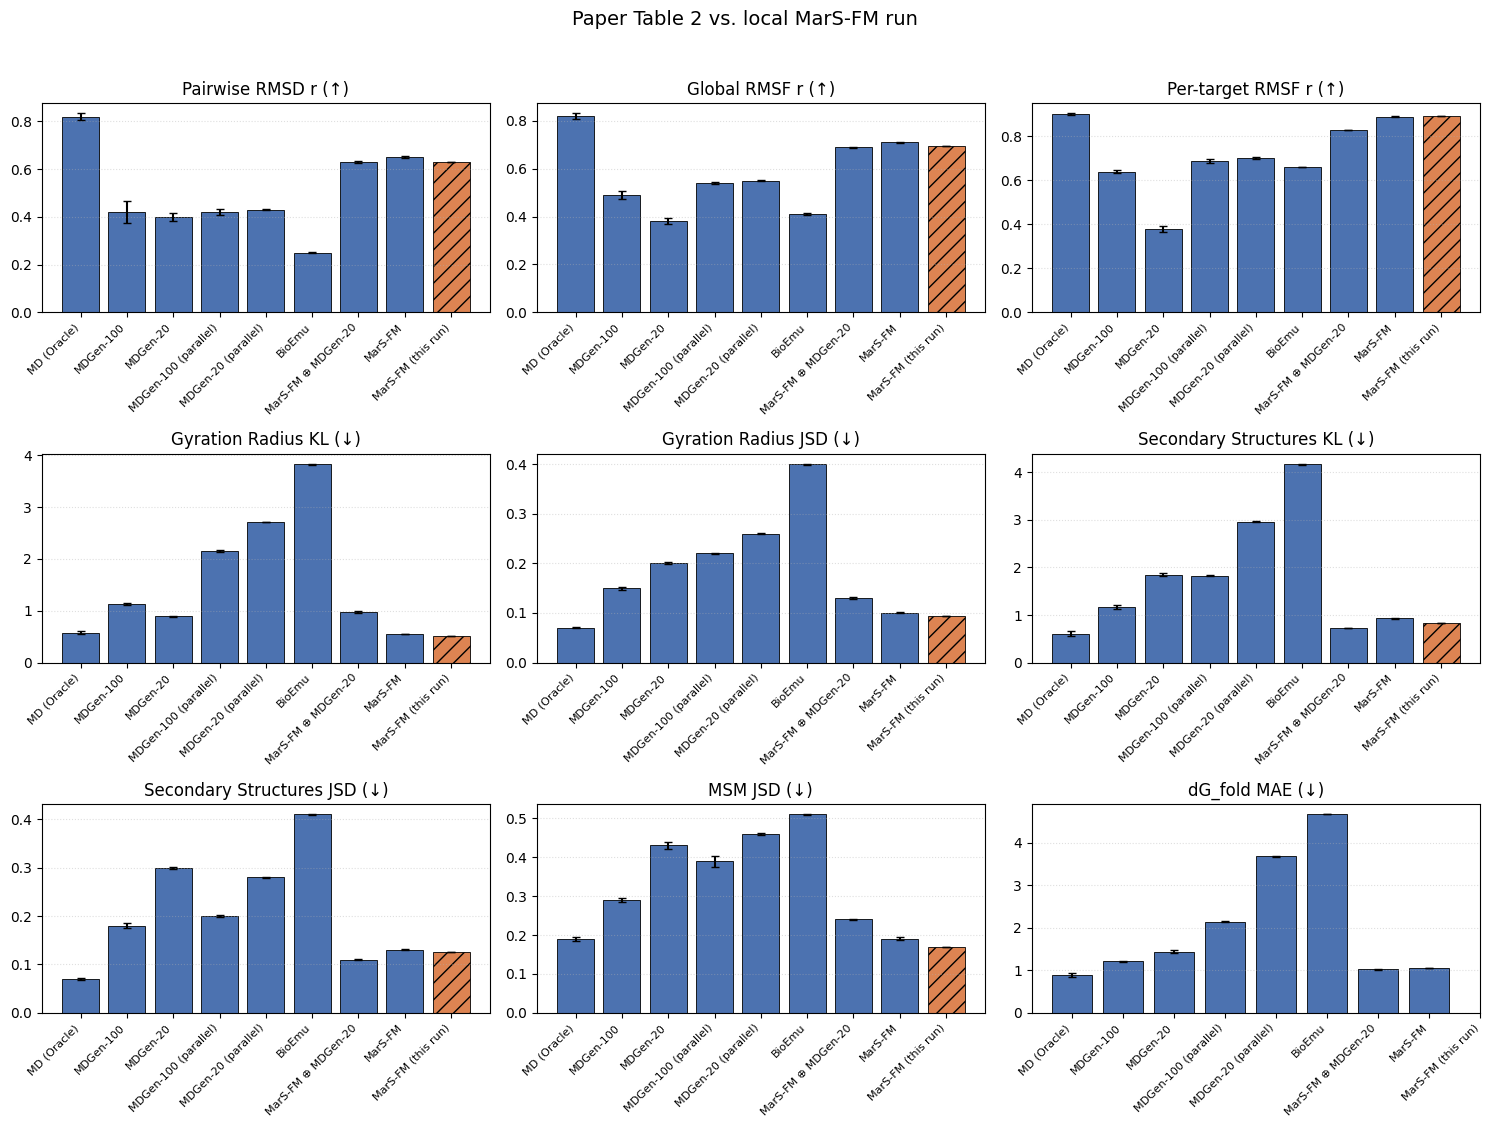

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=False)
models = list(all_means.index)

paper_models = list(paper_means.index)
local_models = list(local_means_df.index)
color_paper = "#4C72B0"
color_local = "#DD8452"
colors = [color_local if m in local_models else color_paper for m in models]
hatches = ["//" if m in local_models else "" for m in models]

for ax, metric in zip(axes.ravel(), METRIC_ORDER):
    means = all_means[metric].values
    errs = all_stds[metric].values
    bars = ax.bar(range(len(models)), means, yerr=errs, capsize=3,
                  color=colors, edgecolor="black", linewidth=0.6)
    for bar, h in zip(bars, hatches):
        if h:
            bar.set_hatch(h)
    arrow = "↑" if METRIC_DIRECTION[metric] == "max" else "↓"
    ax.set_title(f"{metric} ({arrow})")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

fig.suptitle("Paper Table 2 vs. local MarS-FM run", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 5. Delta vs. paper MarS-FM

Quick reference table showing the delta of the local run relative to the paper's
headline MarS-FM row. Positive deltas are good for r-metrics, negative deltas are
good for divergence / MAE metrics.

In [15]:
if local_means_df.empty:
    print("No local CSVs found in workdir_out / workdir_out_ar.")
else:
    ref = paper_means.loc["MarS-FM"]
    deltas = local_means_df.subtract(ref, axis=1)

    def _color_delta(val: float, metric: str) -> str:
        if pd.isna(val):
            return ""
        good = (val > 0) if METRIC_DIRECTION[metric] == "max" else (val < 0)
        return "color: #1b7837" if good else "color: #b00020"

    styled = deltas.style.format("{:+.3f}").apply(
        lambda col: [_color_delta(v, col.name) for v in col], axis=0
    ).set_caption("Local run minus paper MarS-FM (green = better, red = worse)")
    display(styled)

,Pairwise RMSD r,Global RMSF r,Per-target RMSF r,Gyration Radius KL,Gyration Radius JSD,Secondary Structures KL,Secondary Structures JSD,MSM JSD,dG_fold MAE
MarS-FM (this run),-0.019,-0.016,+0.003,-0.029,-0.007,-0.102,-0.004,-0.020,+nan


## 6. Raw CSV preview

Useful for inspecting the per-domain counts and any extra columns produced by
`analyze_mdcath.py` that aren't part of Table 2 (e.g. KL/JSD standard
deviations and dG_fold Pearson r).

In [16]:
for label, paths in LOCAL_CSV_PATHS.items():
    for p in paths:
        if not p.exists():
            continue
        print(f"# {label}: {p.relative_to(REPO_ROOT)}")
        display(pd.read_csv(p))

# MarS-FM (this run): workdir_out/analysis.csv


,count,MD_pairwise_RMSD,Pairwise_RMSD,Pairwise_RMSD_r,MD_RMSF,RMSF,Global_RMSF_r,Per_target_RMSF_r,RMSF_JSD,Pairwise_RMSD_JSD,...,Secondary Structure KL_mean,Secondary Structure KL_std,Secondary Structure JSD_mean,Secondary Structure JSD_std,MSM JSD_mean,MSM JSD_std,MSM KL_mean,MSM KL_std,dG_fold_MAE,dG_fold_r
0,493,15.219,14.843,0.631,10.454,10.360,0.694,0.893,0.250,0.146,...,0.828,1.070,0.126,0.135,0.170,0.173,1.404,2.314,NaN,NaN
